# 01 - Exploratory Data Analysis

TODO: fill in this notebook.

In [1]:
import sys
sys.path.append('../src')

# TODO: your imports here


In [2]:
import os
from pathlib import Path

data_dir = Path("../data/raw")

for folder in data_dir.iterdir():
    if folder.is_dir():
        count = len(list(folder.glob("*.*")))
        print(f"{folder.name}: {count} images")

Fake Notes: 650 images
Real Notes: 950 images


In [3]:
import cv2

bad_files = []

for folder in data_dir.iterdir():
    if folder.is_dir():
        for img_path in folder.glob("*.*"):
            img = cv2.imread(str(img_path))
            if img is None:
                bad_files.append(str(img_path))

print(f"Found {len(bad_files)} corrupted/unreadable images")
if bad_files:
    print("Examples:", bad_files[:5])

Found 0 corrupted/unreadable images


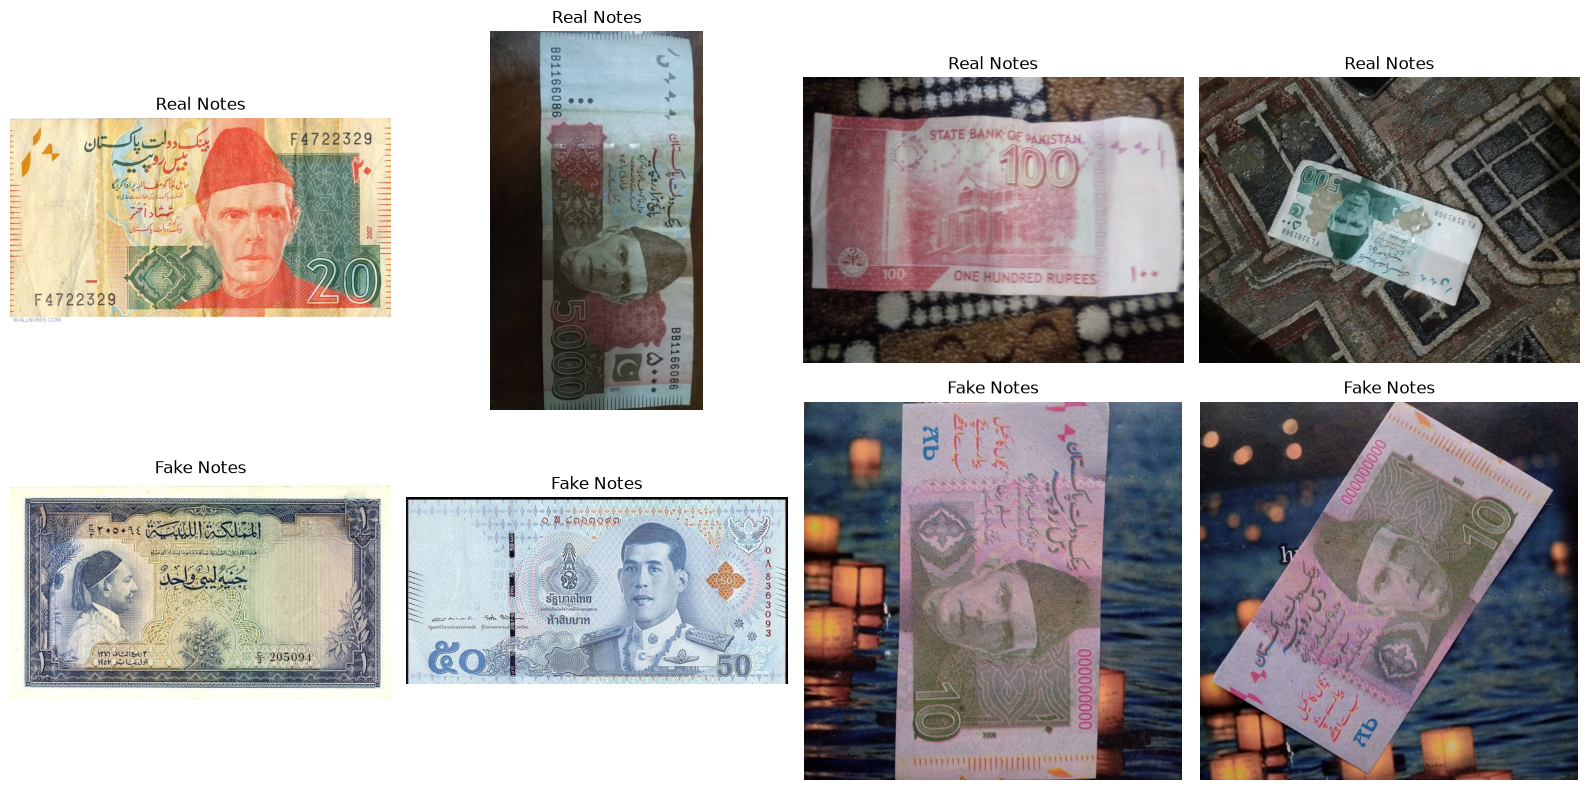

In [4]:
import matplotlib.pyplot as plt
from PIL import Image

fig, axes = plt.subplots(2, 4, figsize=(16, 8))

for row, folder_name in enumerate(["Real Notes", "Fake Notes"]):
    folder_path = data_dir / folder_name
    sample_images = list(folder_path.glob("*.*"))[:4]  # first 4 images
    
    for col, img_path in enumerate(sample_images):
        img = Image.open(img_path)
        axes[row, col].imshow(img)
        axes[row, col].set_title(folder_name)
        axes[row, col].axis("off")

plt.tight_layout()
plt.show()

In [6]:
from PIL import Image

sizes = []

for folder_name in ["Real Notes", "Fake Notes"]:
    folder_path = data_dir / folder_name
    for img_path in list(folder_path.glob("*.*"))[:50]:  # sample 50 per class for speed
        img = Image.open(img_path)
        sizes.append(img.size)  # (width, height)

widths = [s[0] for s in sizes]
heights = [s[1] for s in sizes]

print(f"Width  - min: {min(widths)}, max: {max(widths)}, avg: {sum(widths)//len(widths)}")
print(f"Height - min: {min(heights)}, max: {max(heights)}, avg: {sum(heights)//len(heights)}")

Width  - min: 300, max: 4160, avg: 2050
Height - min: 168, max: 4160, avg: 1975
